# 04 · Analyze, Part B: the remarketing model (D2)

**Decision D2:** which first-time visitors are worth paying to bring back?

Part A ([notebook 03](03_analyze_lab_audit.ipynb)) showed that Google's own model for this question mostly learned to recognize Google employees. This notebook builds the corrected version:

| | Google's lab (GSP229) | This model |
|---|---|---|
| Population | All first visits, employees included | **External** first-time visitors who didn't buy on that visit |
| Label | Bought on *any* later visit, however late | Bought on a later visit **within 30 days** |
| Metric | ROC-AUC | **PR-AUC and lift** (0.3% of visitors buy), then **break-even** |
| Validation | One date split | Time-based folds with a one-month embargo for tuning, then **one** out-of-time test |

Contents: hypotheses H1 and H3 → baselines and three tuned models → one evaluation on the test months, against two no-model rules → robustness checks → drivers → audience composition → break-even → the audience a live campaign would score (no hindsight). How to measure the real lift: [notebook 06](06_test_design.ipynb).

Full write-up: [reports/04_analyze.md](../reports/04_analyze.md), Part B.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

from src import bq, viz
from src.breakeven import CENTRAL, TARGETS, max_affordable_cost, sensitivity, value_by_band, value_of_targets
from src.modeling import (CATEGORICAL_FEATURES, COUNT_FEATURES, CV_FOLDS, LABEL, PIPELINES, TUNING_GRID,
                          TUNING_GRID_EXTENSION, TUNING_GRID_EXTENSION_2, add_features, bootstrap_metric_ci,
                          bootstrap_metric_diff, bottom_share_count, cross_validate, expected_top_share_count,
                          funnel_geo_rule_score, funnel_rule_score, lab_features_pipeline, ranking_metrics,
                          rows_between, top_share_count, top_share_precision, top_share_recall, tune)
from src.tables import remarketing_table

# scikit-learn warns when the test months contain categories unseen in training (handled as "infrequent")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

RUN_TUNING = False   # True re-runs all 28 time-based CV configurations (about 35 minutes)
N_BOOT = 2000

rm = add_features(pd.read_parquet(ROOT / "data/processed/remarketing_table.parquet"))
train, test = rm[rm.split == "train"], rm[rm.split == "test"]
rm.groupby("split").agg(visitors=(LABEL, "size"), buyers_within_30d=(LABEL, "sum"),
                        rate_pct=(LABEL, lambda s: round(100 * s.mean(), 3)),
                        first_day=("session_date", "min"), last_day=("session_date", "max"))

,visitors,buyers_within_30d,rate_pct,first_day,last_day
split,,,,,
test,91431,323,0.353,2017-05-01,2017-07-01
train,522599,1433,0.274,2016-08-01,2017-04-30


## 1. H1: does the first visit's channel predict a later purchase?

Tested on the training months only, so the test months stay untouched. `(Other)` (23 visitors) is left out.

In [2]:
h1 = train[train.channel != "(Other)"]
ct = pd.crosstab(h1.channel, h1[LABEL])
chi2, p, dof, expected = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:,.1f}, df = {dof}, p = {p:.2g}, Cramér's V = {cramers_v:.3f}; "
      f"cells with expected count < 5: {(expected < 5).sum()} of {expected.size} (min {expected.min():.1f})")

by_channel = pd.DataFrame({"visitors": ct.sum(axis=1), "buyers": ct[1]})
by_channel["rate"] = by_channel.buyers / by_channel.visitors
by_channel["ci_low"], by_channel["ci_high"] = proportion_confint(by_channel.buyers, by_channel.visitors, method="wilson")
by_channel = by_channel.sort_values("rate", ascending=False)
by_channel.style.format({"visitors": "{:,}", "rate": "{:.3%}", "ci_low": "{:.3%}", "ci_high": "{:.3%}"})

chi2 = 1,405.6, df = 6, p = 1.5e-300, Cramér's V = 0.052; cells with expected count < 5: 1 of 14 (min 3.7)


,visitors,buyers,rate,ci_low,ci_high
channel,,,,,
Display,"1,332",27,2.027%,1.397%,2.933%
Paid Search,"10,736",125,1.164%,0.978%,1.385%
Direct,"74,248",467,0.629%,0.575%,0.688%
Organic Search,"213,473",773,0.362%,0.338%,0.388%
Referral,"16,441",23,0.140%,0.093%,0.210%
Affiliates,"9,143",3,0.033%,0.011%,0.096%
Social,"197,203",15,0.008%,0.005%,0.013%


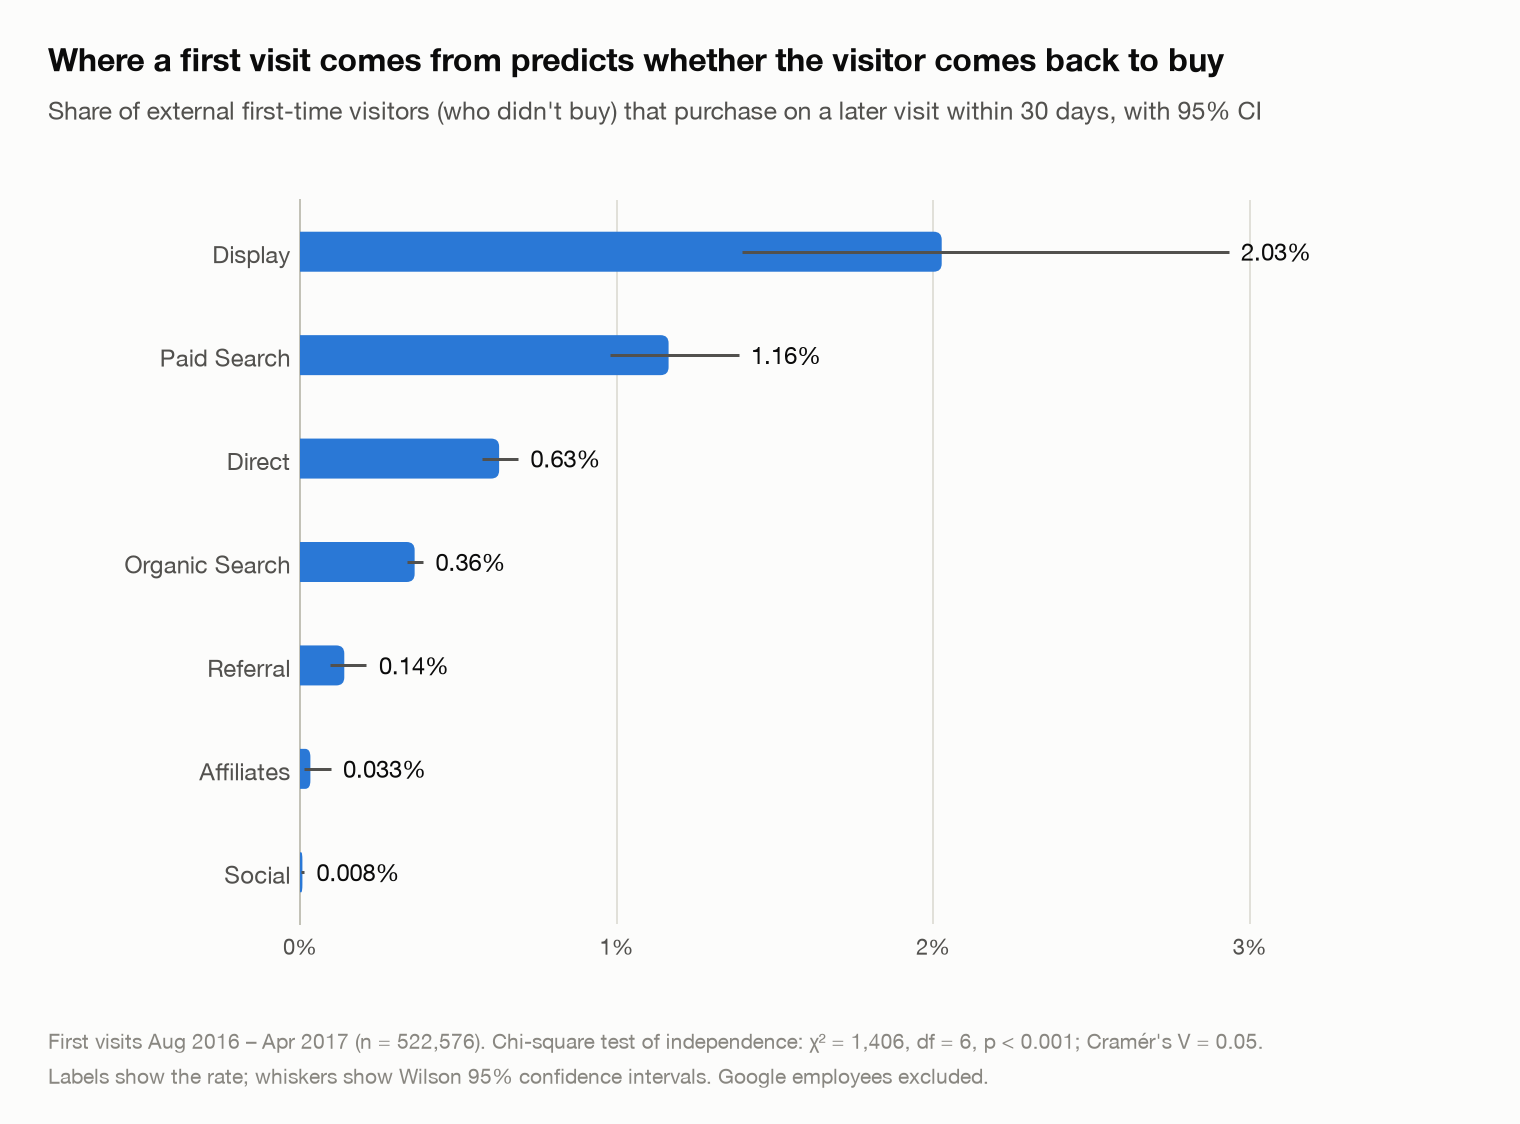

In [3]:
fig = viz.rate_with_ci_chart(
    list(by_channel.index), by_channel.rate.tolist(), by_channel.ci_low.tolist(), by_channel.ci_high.tolist(),
    title="Where a first visit comes from predicts whether the visitor comes back to buy",
    subtitle="Share of external first-time visitors (who didn't buy) that purchase on a later visit within 30 days, with 95% CI",
    note=(f"First visits Aug 2016 – Apr 2017 (n = {by_channel.visitors.sum():,}). Chi-square test of independence: "
          f"χ² = {chi2:,.0f}, df = {dof}, p < 0.001; Cramér's V = {cramers_v:.2f}.\n"
          "Labels show the rate; whiskers show Wilson 95% confidence intervals. Google employees excluded."),
)
viz.show_saved(fig, ROOT / "reports/figures/h1_return_rate_by_channel.png")

**H1 is supported** (p < 0.001, and only 1 of 14 cells has an expected count below 5, which is within Cochran's rule). Cramér's V is 0.05, which sounds negligible, but V is capped by the base rate when the outcome is this rare. The *relative* differences are large: a first visit from Paid Search or Display is followed by a purchase **roughly 150–270× more often** than one from Social, which sends 38% of first-time visitors but only 1% of later buyers.

## 2. H3: does product-level engagement on the first visit predict a later purchase?

In [4]:
rows = []
for flag in ["viewed_product", "added_to_cart"]:
    g = train.groupby(flag)[LABEL].agg(["sum", "size"])
    z, pz = proportions_ztest(g.loc[[1, 0], "sum"].to_numpy(), g.loc[[1, 0], "size"].to_numpy(), alternative="larger")
    r1, r0 = g.loc[1, "sum"] / g.loc[1, "size"], g.loc[0, "sum"] / g.loc[0, "size"]
    rows.append({"engagement": flag, "rate_if_yes": r1, "rate_if_no": r0, "ratio": r1 / r0, "z": z, "p_one_sided": pz})
pd.DataFrame(rows).style.format({"rate_if_yes": "{:.3%}", "rate_if_no": "{:.3%}", "ratio": "{:.1f}x", "z": "{:.1f}", "p_one_sided": "{:.1e}"})

,engagement,rate_if_yes,rate_if_no,ratio,z,p_one_sided
0,viewed_product,1.566%,0.132%,11.9x,59.2,0.0e+00
1,added_to_cart,3.590%,0.170%,21.1x,81.3,0.0e+00


Taken alone, both signals are strong. Do they still matter once overall engagement, channel, device, and region are held constant? A multivariable logistic regression on the training months:

In [5]:
d = train[train.channel != "(Other)"].assign(
    north_america=lambda d: (d.sub_continent == "Northern America").astype(int),
    log_pageviews=lambda d: np.log1p(d.pageviews), log_time=lambda d: np.log1p(d.time_on_site))
logit = smf.logit(f"{LABEL} ~ viewed_product + added_to_cart + reached_checkout + log_pageviews + log_time + bounced"
                  " + north_america + C(device_category) + C(channel, Treatment('Organic Search'))", data=d).fit(disp=0)
odds = pd.DataFrame({"odds_ratio": np.exp(logit.params), "ci_low": np.exp(logit.conf_int()[0]),
                     "ci_high": np.exp(logit.conf_int()[1]), "p_value": logit.pvalues}).drop(index="Intercept")
odds.index = odds.index.str.replace("C(channel, Treatment('Organic Search'))", "channel", regex=False) \
                       .str.replace("C(device_category)", "device", regex=False)
print(f"McFadden pseudo R² = {logit.prsquared:.3f}, n = {int(logit.nobs):,}")
odds.sort_values("odds_ratio", ascending=False).round(3)

McFadden pseudo R² = 0.271, n = 522,576


,odds_ratio,ci_low,ci_high,p_value
north_america,15.684,12.398,19.840,0.000
added_to_cart,3.714,3.190,4.325,0.000
channel[T.Display],2.371,1.587,3.541,0.000
reached_checkout,1.859,1.541,2.242,0.000
channel[T.Direct],1.801,1.599,2.028,0.000
channel[T.Paid Search],1.720,1.415,2.090,0.000
log_pageviews,1.329,1.175,1.503,0.000
log_time,1.229,1.155,1.307,0.000
viewed_product,1.163,0.995,1.359,0.057
bounced,1.013,0.753,1.362,0.931


**H3 is supported only in part.** Adding to cart **multiplies the odds of a later purchase by 3.7** (95% CI 3.2–4.3) even after controls, and reaching checkout adds a further 1.9×. **Merely viewing a product is no longer significant** (odds ratio 1.16, p = 0.06): its effect in the simple comparison came from general engagement. The strongest single factor is geography: **a first visit from North America multiplies the odds by 15.7**. Mobile first visits have 64% lower odds than desktop.

## 3. Tuning: time-based validation inside the training months

Each fold trains on earlier months, skips one month (an embargo, because training labels look 30 days ahead), and validates on the next two months. Selection rule, fixed before the test set is touched: **the highest mean validation PR-AUC**.

In [6]:
print("Folds (train → embargo → validate):")
for (a, b), (c, e) in CV_FOLDS:
    print(f"  {a} .. {b}  →  validate {c} .. {e}: {len(rows_between(train, c, e)):,} visitors, "
          f"{rows_between(train, c, e)[LABEL].sum()} buyers")

tuning_path = ROOT / "data/processed/tuning_results.json"
if RUN_TUNING:
    parts = [tune(train, grid).assign(grid_pass=i)
             for i, grid in enumerate([TUNING_GRID, TUNING_GRID_EXTENSION, TUNING_GRID_EXTENSION_2], start=1)]
    pd.concat(parts, ignore_index=True).to_json(tuning_path, orient="records", indent=1)
elif not tuning_path.exists():
    raise FileNotFoundError("data/processed/tuning_results.json is missing: restore the committed file "
                            "(git restore data/processed) or set RUN_TUNING = True to re-run the tuning (about 35 minutes)")
tuning = pd.read_json(tuning_path)
tuning["params"] = tuning.params.astype(str)
print(f"{len(tuning)} configurations evaluated")
tuning.sort_values(["model", "cv_pr_auc"], ascending=[True, False]).groupby("model").head(3)[
    ["model", "params", "cv_pr_auc", "cv_roc_auc", "fold_pr_auc", "grid_pass"]].round(4)

Folds (train → embargo → validate):
  2016-08-01 .. 2016-10-31  →  validate 2016-12-01 .. 2017-01-31: 100,094 visitors, 313 buyers
  2016-08-01 .. 2016-12-31  →  validate 2017-02-01 .. 2017-03-31: 97,199 visitors, 271 buyers
  2016-08-01 .. 2017-01-31  →  validate 2017-03-01 .. 2017-04-30: 101,102 visitors, 286 buyers
28 configurations evaluated


,model,params,cv_pr_auc,cv_roc_auc,fold_pr_auc,grid_pass
23,gradient_boosting,"{'learning_rate': 0.02, 'max_leaf_nodes': 4, '...",0.0701,0.9171,"[0.0591, 0.0683, 0.083]",3
27,gradient_boosting,"{'learning_rate': 0.02, 'max_leaf_nodes': 3, '...",0.0698,0.9181,"[0.058800000000000005, 0.0668, 0.0839]",3
22,gradient_boosting,"{'learning_rate': 0.02, 'max_leaf_nodes': 7, '...",0.0690,0.9177,"[0.0579, 0.0666, 0.0824]",2
0,logistic_regression,{'C': 0.01},0.0673,0.9172,"[0.0597, 0.0654, 0.07690000000000001]",1
3,logistic_regression,{'C': 10.0},0.0668,0.9213,"[0.06520000000000001, 0.0582, 0.077]",1
2,logistic_regression,{'C': 1.0},0.0666,0.9221,"[0.0649, 0.0594, 0.0757]",1
17,random_forest,"{'min_samples_leaf': 10, 'max_features': 'sqrt'}",0.0706,0.9139,"[0.0603, 0.066, 0.0855]",2
4,random_forest,"{'min_samples_leaf': 20, 'max_features': 'sqrt'}",0.0692,0.9164,"[0.058, 0.0663, 0.08320000000000001]",1
5,random_forest,"{'min_samples_leaf': 20, 'max_features': 0.300...",0.0670,0.9024,"[0.053500000000000006, 0.067, 0.0806]",1


The first grid's best tree models sat at its edge (the most regularized boosting, the smallest-leaf forest), so the grid was extended in that direction until the optimum was interior. Boosting improves steadily as trees get *smaller*, down to 4 leaves; 2-leaf stumps are worse. So the signal is **mostly additive, with small interactions**, which is why plain logistic regression comes close.

In [7]:
best = pd.read_json(tuning_path)
best = best.loc[best.groupby("model").cv_pr_auc.idxmax()].set_index("model")
chosen = best.cv_pr_auc.idxmax()

baseline_cv = {}
for name, rule in [("Funnel rule", funnel_rule_score), ("Funnel + geo rule", funnel_geo_rule_score)]:
    baseline_cv[name] = np.mean([average_precision_score(rows_between(train, c, e)[LABEL], rule(rows_between(train, c, e)))
                                 for _, (c, e) in CV_FOLDS])
baseline_cv["Lab features (refit)"] = cross_validate(lab_features_pipeline, train)["cv_pr_auc"]
summary = pd.concat([pd.Series(baseline_cv, name="cv_pr_auc"), best.cv_pr_auc]).sort_values(ascending=False)
print("Chosen by the rule:", chosen)
summary.round(4).to_frame()

Chosen by the rule: random_forest


,cv_pr_auc
random_forest,0.0706
gradient_boosting,0.0701
logistic_regression,0.0673
Lab features (refit),0.0560
Funnel + geo rule,0.0467
Funnel rule,0.0277


## 4. One evaluation on the test months (May 1 – July 1, 2017)

All models are refit on the full training months and scored once on the test months. Two baselines need no model at all:

- **Funnel rule:** rank first visits by the furthest funnel step they reached, then by pageviews. Beating it is the Ask-phase success criterion.
- **North America + funnel rule** (`Funnel + geo rule` in the tables): North American first visits first, then the funnel rule. It encodes the two strongest signals of the H3 regression, region and how far the visit got, so it's the benchmark to beat.

In [8]:
scores = {"Funnel rule": funnel_rule_score(test), "Funnel + geo rule": funnel_geo_rule_score(test),
          "Lab features (refit)": lab_features_pipeline().fit(train, train[LABEL]).predict_proba(test)[:, 1]}
fitted = {}
for name, row in best.iterrows():
    fitted[name] = PIPELINES[name](**row.params).fit(train, train[LABEL])
    scores[name] = fitted[name].predict_proba(test)[:, 1]
y = test[LABEL].to_numpy()

results = pd.DataFrame({k: ranking_metrics(y, s) for k, s in scores.items()}).T
ci = {k: bootstrap_metric_ci(y, s, average_precision_score, n_boot=N_BOOT) for k, s in scores.items()}
results.insert(1, "pr_auc_ci_low", [ci[k][0] for k in results.index])
results.insert(2, "pr_auc_ci_high", [ci[k][1] for k in results.index])
results.style.format({"pr_auc": "{:.4f}", "pr_auc_ci_low": "{:.4f}", "pr_auc_ci_high": "{:.4f}", "roc_auc": "{:.3f}",
                      "precision_top_1pct": "{:.1%}", "lift_top_1pct": "{:.1f}x", "lift_top_5pct": "{:.1f}x",
                      "lift_top_10pct": "{:.1f}x", "recall_top_10pct": "{:.1%}"})

,pr_auc,pr_auc_ci_low,pr_auc_ci_high,roc_auc,precision_top_1pct,lift_top_1pct,lift_top_5pct,lift_top_10pct,recall_top_10pct
Funnel rule,0.0283,0.0214,0.0418,0.806,4.3%,12.1x,8.4x,5.4x,53.9%
Funnel + geo rule,0.0493,0.0374,0.0703,0.880,7.4%,21.1x,9.5x,6.1x,61.3%
Lab features (refit),0.0553,0.0420,0.0771,0.901,8.3%,23.5x,10.6x,6.5x,65.0%
gradient_boosting,0.0624,0.0479,0.0860,0.902,9.6%,27.3x,11.0x,6.8x,67.8%
logistic_regression,0.0631,0.0481,0.0851,0.912,8.9%,25.1x,11.0x,7.0x,69.7%
random_forest,0.0607,0.0474,0.0824,0.912,9.6%,27.3x,10.8x,7.0x,70.0%


In [9]:
precision_top_10 = lambda yy, ss: top_share_precision(yy, ss, 0.10)   # used for the top-decile lift in §5
recall_top_10 = lambda yy, ss: top_share_recall(yy, ss, 0.10)         # share of later buyers in the top 10%
comparisons = {}
for base in ["Funnel rule", "Funnel + geo rule", "Lab features (refit)"]:
    for metric_name, metric in [("PR-AUC", average_precision_score), ("recall in top 10%", recall_top_10)]:
        comparisons[(f"{chosen} − {base}", metric_name)] = bootstrap_metric_diff(y, scores[chosen], scores[base], metric,
                                                                                n_boot=N_BOOT)
pd.DataFrame(comparisons).T.round(4)

diff  ci_low  ci_high  p_diff_le_0
random_forest − Funnel rule          PR-AUC             0.0324  0.0192   0.0480       0.0000
                                     recall in top 10%  0.1610  0.1205   0.2110       0.0000
random_forest − Funnel + geo rule    PR-AUC             0.0114 -0.0019   0.0248       0.0450
                                     recall in top 10%  0.0867  0.0444   0.1346       0.0000
random_forest − Lab features (refit) PR-AUC             0.0054 -0.0080   0.0178       0.1970
                                     recall in top 10%  0.0495  0.0118   0.0846       0.0095

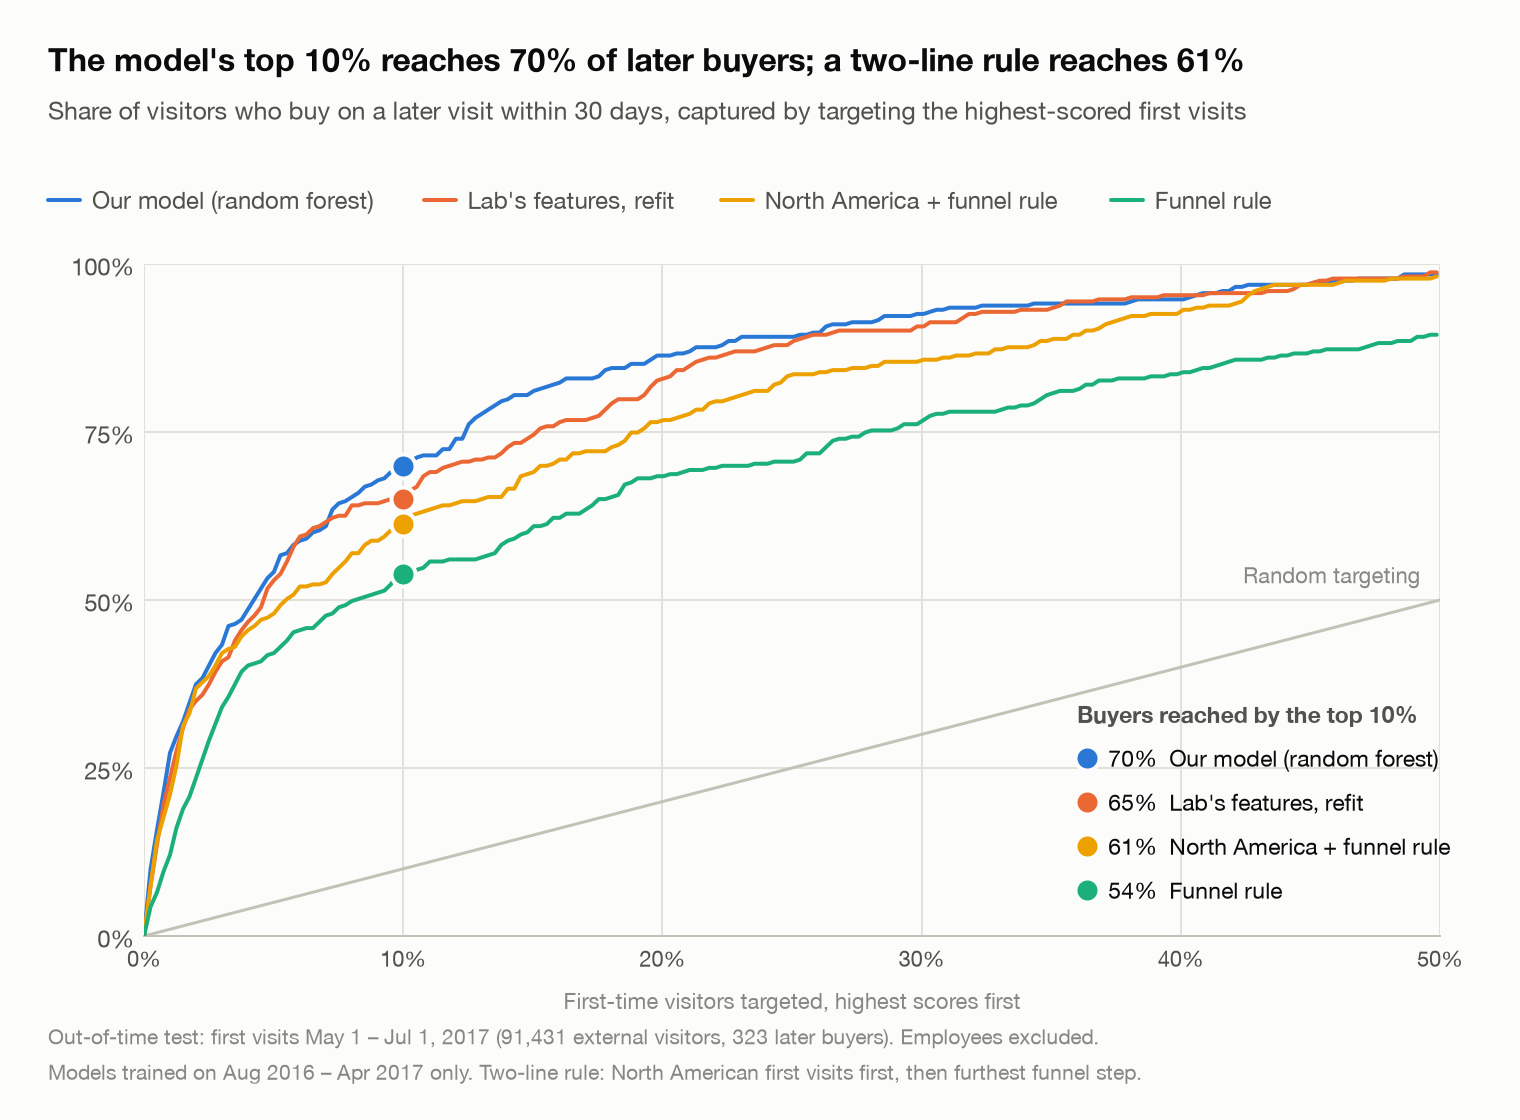

In [10]:
# Four rankings are more than viz.gains_chart's in-plot value key has room for, so this chart is drawn here in the
# same style, with the key in the empty corner under the random-targeting line.
labels = {chosen: "Our model (random forest)" if chosen == "random_forest" else f"Our model ({chosen})",
          "Lab features (refit)": "Lab's features, refit", "Funnel + geo rule": "North America + funnel rule",
          "Funnel rule": "Funnel rule"}
colors = {chosen: viz.SERIES_1, "Lab features (refit)": "#eb6834", "Funnel + geo rule": "#eda100",
          "Funnel rule": "#1baf7a"}   # reference palette slots 1, 2, 4, 3: the earlier series keep their colors
reach = {k: top_share_recall(y, scores[k], 0.10) for k in labels}

viz.apply_style()
fig, ax = viz.figure(760, 560, plot_box=(72, 132, 40, 92))
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1)
ax.set_xticks(np.linspace(0, 0.5, 6), [f"{t:.0%}" for t in np.linspace(0, 0.5, 6)])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.grid(axis="both", zorder=0)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(viz.AXIS)
ax.set_xlabel("First-time visitors targeted, highest scores first", fontsize=viz.px(11), color=viz.MUTED, labelpad=6)
ax.plot([0, 0.5], [0, 0.5], color=viz.AXIS, lw=viz.px(1.5), zorder=2)
ax.text(0.4925, 0.5175, "Random targeting", ha="right", va="bottom", fontsize=viz.px(11), color=viz.MUTED)
ax.axvline(0.10, color=viz.AXIS, lw=viz.px(1), zorder=1)
for k in labels:
    share, captured = viz.cumulative_gains(y, scores[k])
    ax.plot(share[share <= 0.5], captured[share <= 0.5], color=colors[k], lw=viz.px(2), solid_joinstyle="round",
            solid_capstyle="round", zorder=3)
    viz.dot(ax, 0.10, reach[k], colors[k], diameter_px=8)
kx, ky, row = 0.36, 0.33, 22 / 336   # value key: one row per 22 px of the 336-px-tall plot
ax.text(kx, ky, "Buyers reached by the top 10%", ha="left", va="center", fontsize=viz.px(11.5), color=viz.INK_2,
        fontweight="bold")
for i, k in enumerate(sorted(labels, key=lambda k: -reach[k]), start=1):
    viz.dot(ax, kx + 0.004, ky - i * row, colors[k], diameter_px=8)
    ax.text(kx + 0.012, ky - i * row, f"{reach[k]:.0%}  {labels[k]}", ha="left", va="center", fontsize=viz.px(11.5),
            color=viz.INK)

viz.header(fig, f"The model's top 10% reaches {reach[chosen]:.0%} of later buyers; a two-line rule reaches "
                f"{reach['Funnel + geo rule']:.0%}",
           "Share of visitors who buy on a later visit within 30 days, captured by targeting the highest-scored first visits")
w, h = fig.get_size_inches() * viz.PX_PER_IN
lx = 24
for k in labels:   # legend row under the subtitle
    fig.add_artist(Line2D([lx / w, (lx + 16) / w], [1 - 100 / h] * 2, color=colors[k], lw=viz.px(2),
                          transform=fig.transFigure, solid_capstyle="round"))
    t = fig.text((lx + 22) / w, 1 - 100 / h, labels[k], ha="left", va="center", fontsize=viz.px(12), color=viz.INK_2)
    fig.canvas.draw()
    lx += 22 + t.get_window_extent().width / (fig.dpi / viz.PX_PER_IN) + 26
viz.footnote(fig, f"Out-of-time test: first visits May 1 – Jul 1, 2017 ({len(test):,} external visitors, {int(y.sum())} "
                  "later buyers). Employees excluded.\nModels trained on Aug 2016 – Apr 2017 only. Two-line rule: North "
                  "American first visits first, then furthest funnel step.")
viz.show_saved(fig, ROOT / "reports/figures/d2_gains_chart.png")

**Against the success criterion** ([Ask](../reports/01_ask.md)): the model clearly beats the simple funnel rule, with PR-AUC more than doubled and top-decile lift 7.0× vs 5.4×. The criterion is met.

**Against the North America + funnel rule**, the edge is much smaller. The rule's top 10% holds 61% of later buyers against the forest's 70%, and that 8.7-point gap is significant (95% CI +4.4 to +13.5). The PR-AUC gain (+0.011, 95% CI −0.002 to +0.025) is not. Two lines of logic get most of the way, and the model's contribution is a sharper top of the ranking.

**Against the lab's feature set refit on our corrected data**, the gain is also small. PR-AUC is not significantly higher. The share of later buyers in the top 10% is significantly higher, but only by 5 points (70% vs 65%, 95% CI +1.2 to +8.5). Once the population and label are fixed, even the lab's simple features get most of the way. **The big improvement came from correcting the data, not from a more complex model.**

The three model families are statistically tied on the test months, and the validation winner (the random forest) isn't the test winner. That's what noise looks like when the real differences are small.

## 5. Robustness

In [11]:
# (a) Embargo: train only on first visits whose 30-day label had closed before the test months began
embargo_train = rows_between(train, "2016-08-01", "2017-03-31")
s_embargo = PIPELINES[chosen](**best.loc[chosen, "params"]).fit(embargo_train, embargo_train[LABEL]).predict_proba(test)[:, 1]

# (b) Residual employees: visitors our flag missed but the lab's unredacted table identifies (Part A)
truth = set(bq.query("audit/a14_true_internal_visitors.sql", cache="a14_true_internal_visitors").full_visitor_id)
keep = ~test.full_visitor_id.isin(truth).to_numpy()

pd.DataFrame({
    "PR-AUC": [average_precision_score(y, scores[chosen]), average_precision_score(y, s_embargo),
               average_precision_score(y[keep], scores[chosen][keep])],
    "lift top 10%": [precision_top_10(y, scores[chosen]) / y.mean(), precision_top_10(y, s_embargo) / y.mean(),
                     precision_top_10(y[keep], scores[chosen][keep]) / y[keep].mean()],
    "visitors": [len(y), len(y), int(keep.sum())],
}, index=["main result", "trained through 2017-03-31 (embargo)", f"without {int((~keep).sum())} missed employees"]).round(4)

,PR-AUC,lift top 10%,visitors
main result,0.0607,6.9970,91431
trained through 2017-03-31 (embargo),0.0583,6.8112,91431
without 298 missed employees,0.0614,7.0222,91133


In [12]:
# (c) Calibration: predicted vs observed 30-day purchase rate by score decile
p = scores[chosen]
decile = 9 - pd.qcut(pd.Series(p).rank(method="first"), 10, labels=False)
calibration = pd.DataFrame({"p": p, "y": y, "decile": decile.to_numpy() + 1}).groupby("decile").agg(
    visitors=("y", "size"), buyers=("y", "sum"), predicted=("p", "mean"), observed=("y", "mean"))
print(f"Brier score {brier_score_loss(y, p):.5f}; mean predicted {p.mean():.3%} vs observed {y.mean():.3%}")
calibration.style.format({"predicted": "{:.3%}", "observed": "{:.3%}"})

Brier score 0.00340; mean predicted 0.343% vs observed 0.353%


,visitors,buyers,predicted,observed
decile,,,,
1,9143,226,2.303%,2.472%
2,9143,52,0.535%,0.569%
3,9143,21,0.301%,0.230%
4,9143,7,0.163%,0.077%
5,9143,12,0.099%,0.131%
6,9143,5,0.025%,0.055%
7,9143,0,0.005%,0.000%
8,9143,0,0.001%,0.000%
9,9143,0,0.000%,0.000%


In [13]:
# (d) Precision of the two headline shares: Wilson 95% intervals across the 323 later buyers, with the score cut fixed.
#     Cuts break ties by row order; the last column is the count expected if tied scores were ordered at random.
n_buyers = int(y.sum())
rows = []
for name in [chosen, "Funnel + geo rule", "Funnel rule"]:
    s = scores[name]
    for where, count, if_random in [("top 10%", top_share_count(y, s, 0.10), expected_top_share_count(y, s, 0.10)),
                                    ("bottom 40%", bottom_share_count(y, s, 0.40),
                                     n_buyers - expected_top_share_count(y, s, 0.60))]:
        low, high = proportion_confint(count, n_buyers, method="wilson")
        rows.append({"ranking": name, "later buyers in": where, "count": count, "share": count / n_buyers,
                     "wilson_low": low, "wilson_high": high, "count_if_ties_random": if_random})
pd.DataFrame(rows).style.format({"share": "{:.1%}", "wilson_low": "{:.1%}", "wilson_high": "{:.1%}",
                                 "count_if_ties_random": "{:.1f}"})

,ranking,later buyers in,count,share,wilson_low,wilson_high,count_if_ties_random
0,random_forest,top 10%,226,70.0%,64.8%,74.7%,226.0
1,random_forest,bottom 40%,0,0.0%,0.0%,1.2%,0.0
2,Funnel + geo rule,top 10%,198,61.3%,55.9%,66.4%,197.8
3,Funnel + geo rule,bottom 40%,0,0.0%,0.0%,1.2%,0.6
4,Funnel rule,top 10%,174,53.9%,48.4%,59.2%,172.7
5,Funnel rule,bottom 40%,29,9.0%,6.3%,12.6%,30.8


- **Look-ahead:** training labels from late April look into May. Training only on months whose labels closed before May gives PR-AUC 0.058 against 0.061, slightly lower because it has a month less data. The overlap didn't inflate the result.
- **Leftover employees:** removing the 298 test visitors whom the lab's table identifies as employees barely changes anything.
- **Calibration:** predicted and observed rates agree overall and by decile. **The bottom 40% of scored visitors produced no later buyers at all.**
- **Precision of the headline shares:** 226 of 323 later buyers (70.0%) rank in the top 10%, 95% Wilson interval 64.8–74.7%. None rank in the bottom 40%, and with 95% confidence at most 1.2% of later buyers (about 4 of 323) sit there. The empty bottom 40% isn't a model achievement, though: the North America + funnel rule leaves no later buyer there either (0.6 expected if its tied scores were ordered at random).

A bigger question is the employee flag itself, which uses hindsight. Section 9 re-runs the evaluation without it.

## 6. What drives the score

Permutation importance measures how much test-month PR-AUC drops when one input is shuffled. Correlated inputs (pageviews, hits, time on site) share credit, so they each look smaller than their combined effect.

In [14]:
cols = COUNT_FEATURES + ["bounced"] + CATEGORICAL_FEATURES
pi = permutation_importance(fitted[chosen], test[cols], test[LABEL], scoring="average_precision",
                            n_repeats=5, random_state=42, n_jobs=1)
importance = pd.DataFrame({"feature": cols, "pr_auc_drop": pi.importances_mean, "sd": pi.importances_std}) \
    .sort_values("pr_auc_drop", ascending=False)
importance.round(4)

,feature,pr_auc_drop,sd
13,country,0.0125,0.0034
12,sub_continent,0.0101,0.0031
14,max_ecommerce_step,0.0069,0.0016
10,operating_system,0.0066,0.0010
5,add_to_cart_events,0.0051,0.0006
8,channel,0.0044,0.0016
9,device_category,0.0032,0.0006
2,time_on_site,0.0031,0.0002
11,browser,0.0024,0.0011
4,distinct_products_viewed,0.0005,0.0001


In [15]:
os_rates = train.groupby(["sub_continent", "operating_system"])[LABEL].agg(visitors="size", buyers="sum")
os_rates = os_rates.loc["Northern America"].query("visitors >= 500").assign(rate=lambda d: d.buyers / d.visitors)
os_rates.sort_values("rate", ascending=False).style.format({"visitors": "{:,}", "rate": "{:.2%}"})

,visitors,buyers,rate
operating_system,,,
Macintosh,"40,131",607,1.51%
Chrome OS,"7,483",88,1.18%
Windows,"54,538",396,0.73%
Linux,"6,722",40,0.60%
Android,"26,110",112,0.43%
iOS,"32,429",113,0.35%


**Geography dominates** (country and sub-continent), followed by **how far into the funnel the first visit got**, **operating system**, add-to-cart, and channel.

The operating-system signal is real rather than leftover employees: within North America, Mac first visits come back to buy at 1.5% and Chrome OS at 1.2%, against 0.7% for Windows and 0.3–0.4% for phones. The employees our flag missed are too few to explain this (about 1% of buyers).

## 7. Who would be in the audience?

In [16]:
order = np.argsort(-scores[chosen], kind="stable")
top10 = test.iloc[order[: int(round(0.10 * len(test)))]]
for col in ["sub_continent", "device_category", "channel"]:
    mix = pd.DataFrame({"top 10% by score": top10[col].value_counts(normalize=True),
                        "all first-time visitors": test[col].value_counts(normalize=True)}).fillna(0)
    display(mix.sort_values("top 10% by score", ascending=False).head(5).style.format("{:.1%}"))

,top 10% by score,all first-time visitors
sub_continent,,
Northern America,91.1%,41.9%
South America,1.6%,4.0%
Eastern Asia,1.4%,6.2%
Southern Asia,1.0%,9.1%
Western Europe,0.8%,8.4%


,top 10% by score,all first-time visitors
device_category,,
desktop,81.5%,61.8%
mobile,15.6%,33.7%
tablet,2.8%,4.5%


,top 10% by score,all first-time visitors
channel,,
Organic Search,51.1%,60.9%
Direct,32.0%,21.9%
Paid Search,12.1%,3.8%
Referral,2.0%,4.8%
Social,1.4%,6.4%


The top 10% is **91% North American** (against 42% of first-time visitors), **82% desktop** (against 62%), and over-represents Paid Search and Direct. This follows purchase behavior. Visitors from other regions almost never come back to buy, perhaps because of shipping or pricing, which the data can't show. It still means the audience is geographically narrow in practice, so the Act phase should state that openly rather than let it happen silently. The low mobile share is also worth a UX check, since mobile first visits convert far less often.

## 8. Break-even: what is one retargeted visitor worth?

**Decision D-B2 (you chose this):** report the **maximum affordable cost per visitor** for each score band, instead of assuming a cost.

> remarketing pays off when revenue per visitor (next 30 days) × incremental lift × gross margin ≥ cost per visitor

- **Revenue per visitor** is measured, not modeled: what each band actually spent in the 30 days after the first visit, in the test months, capped per visitor at $1,606 (D-P2).
- **Lift** is 10% in the central case, anchored on randomized experiments: a display-retargeting campaign lifted purchases 10.5% (Johnson, Lewis & Nubbemeyer 2017), and the median conversion lift across 432 Google Display Network experiments was 8%.
- **Gross margin** is 50% in the central case. The store's real margin isn't public, so the sensitivity table covers 30–70%.

In [17]:
bands = value_by_band(y, test.revenue_30d_usd.to_numpy(), scores[chosen], n_boot=N_BOOT)
months = (test.session_date.max() - test.session_date.min()).days / 30.4
bands["visitors_per_month"] = bands.visitors / months
bands["max_cost_central"] = max_affordable_cost(bands.revenue_per_visitor, **CENTRAL)
bands.style.format({"visitors": "{:,}", "buy_rate": "{:.2%}", "revenue_per_visitor": "${:.2f}", "rpv_ci_low": "${:.2f}",
                    "rpv_ci_high": "${:.2f}", "visitors_per_month": "{:,.0f}", "max_cost_central": "${:.3f}"})

,band,visitors,buyers,buy_rate,revenue_per_visitor,rpv_ci_low,rpv_ci_high,visitors_per_month,max_cost_central
0,Top 1%,914,88,9.63%,$14.07,$8.93,$20.62,456,$0.703
1,1%–2%,915,33,3.61%,$3.59,$1.68,$5.94,456,$0.180
2,2%–5%,"2,743",54,1.97%,$2.24,$1.14,$3.78,"1,367",$0.112
3,5%–10%,"4,571",51,1.12%,$1.35,$0.71,$2.30,"2,278",$0.067
4,10%–20%,"9,143",53,0.58%,$1.39,$0.74,$2.17,"4,557",$0.069
5,20%–50%,"27,430",39,0.14%,$0.09,$0.06,$0.13,"13,670",$0.005
6,50%–100%,"45,715",5,0.01%,$0.01,$0.00,$0.02,"22,783",$0.000


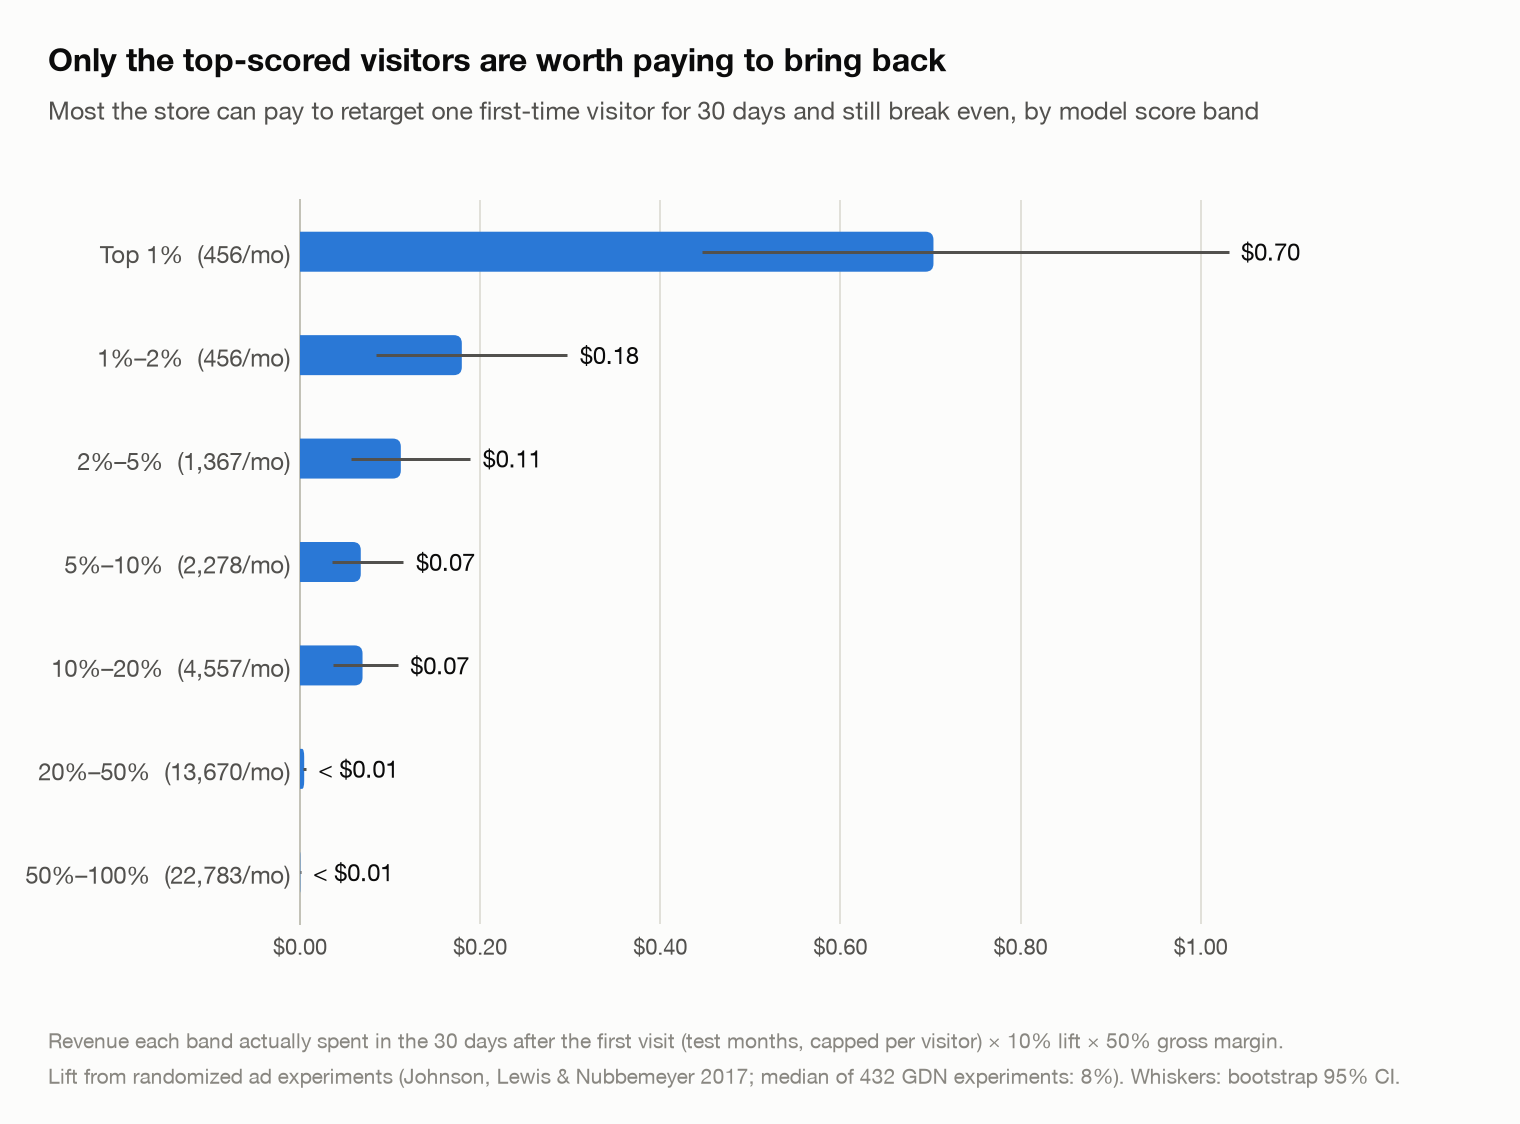

In [18]:
k = CENTRAL["lift"] * CENTRAL["margin"]
fig = viz.rate_with_ci_chart(
    [f"{b}  ({v:,.0f}/mo)" for b, v in zip(bands.band, bands.visitors_per_month)],
    (bands.revenue_per_visitor * k).tolist(), (bands.rpv_ci_low * k).tolist(), (bands.rpv_ci_high * k).tolist(),
    title="Only the top-scored visitors are worth paying to bring back",
    subtitle="Most the store can pay to retarget one first-time visitor for 30 days and still break even, by model score band",
    note=("Revenue each band actually spent in the 30 days after the first visit (test months, capped per visitor) × 10% lift × 50% gross margin.\n"
          "Lift from randomized ad experiments (Johnson, Lewis & Nubbemeyer 2017; median of 432 GDN experiments: 8%). Whiskers: bootstrap 95% CI."),
    value_fmt=lambda v: f"${v:.2f}" if v >= 0.01 else "< $0.01", tick_fmt=lambda t: f"${t:.2f}",
)
viz.show_saved(fig, ROOT / "reports/figures/d2_breakeven_by_band.png")

**Sensitivity:** the maximum affordable cost per visitor (USD) for each band under every lift and margin scenario.

In [19]:
sensitivity(bands).round(3)

margin 30%                                    margin 50%                                    margin 70%                                   
            lift 5% lift 8% lift 10% lift 15% lift 20%    lift 5% lift 8% lift 10% lift 15% lift 20%    lift 5% lift 8% lift 10% lift 15% lift 20%
band                                                                                                                                              
Top 1%        0.211   0.338    0.422    0.633    0.844      0.352   0.563    0.703    1.055    1.407      0.492   0.788    0.985    1.477    1.969
1%–2%         0.054   0.086    0.108    0.162    0.216      0.090   0.144    0.180    0.269    0.359      0.126   0.201    0.252    0.377    0.503
2%–5%         0.034   0.054    0.067    0.101    0.134      0.056   0.090    0.112    0.168    0.224      0.078   0.125    0.157    0.235    0.313
5%–10%        0.020   0.032    0.040    0.061    0.081      0.034   0.054    0.067    0.101    0.135      0.047   0.076    0.094    0.142    0.189
10%–20%       0.021   0.033    0.042    0.062    0.083      0.035   0.056    0.069    0.104    0.139      0.049   0.078    0.097    0.146    0.194
20%–50%       0.001   0.002    0.003    0.004    0.006      0.002   0.004    0.005    0.007    0.009      0.003   0.005    0.007    0.010    0.013
50%–100%      0.000   0.000    0.000    0.000    0.000      0.000   0.000    0.000    0.001    0.001      0.000   0.000    0.001    0.001    0.001

**What each audience is worth per month:** extra gross profit before ad cost from retargeting the top 1%, 5%, 10% or 20% of scored first visits, in the central case. The 95% CI is a bootstrap over the visitors in the audience, so it covers noise in what they spent. The range covers the sensitivity grid (lift 5–20%, margin 30–70%).

In [20]:
targets = value_of_targets(y, test.revenue_30d_usd.to_numpy(), scores[chosen], months, n_boot=N_BOOT)
targets.style.format({"visitors_per_month": "{:,.0f}", "share_of_later_buyers": "{:.0%}", "revenue_per_visitor": "${:.2f}",
                      "gross_profit_per_month": "${:,.0f}", "ci_low": "${:,.0f}", "ci_high": "${:,.0f}",
                      "range_low": "${:,.0f}", "range_high": "${:,.0f}"})

,target,visitors_per_month,share_of_later_buyers,revenue_per_visitor,gross_profit_per_month,ci_low,ci_high,range_low,range_high
0,top 1%,456,27%,$14.07,$320,$203,$470,$96,$897
1,top 5%,"2,279",54%,$4.87,$555,$401,$747,$167,"$1,555"
2,top 10%,"4,557",70%,$3.11,$709,$523,$910,$213,"$1,985"
3,top 20%,"9,113",86%,$2.25,"$1,025",$779,"$1,292",$308,"$2,871"


**Scope of the dollar figure.** The $709 a month is the value of the **top 10%** (about 4,600 visitors a month, 95% CI $523–$910), not of retargeting in general. Widening to the **top 20%** (about 9,100 a month) raises it to about **$1,025** ($779–$1,292). The assumed lift and margin matter more than sampling noise: across lifts of 5–20% and margins of 30–70%, the top 10% is worth **$213–$1,985** a month and the top 20% **$308–$2,871**. Either way, retargeting is worth hundreds to low thousands of dollars a month before ad costs, not a major budget line.

## 9. Robustness: the audience without hindsight

The population above leaves out Google employees with a **whole-year** flag: a visitor is internal if *any* of their sessions in the year arrives through the internal link. For a first-time visitor, that flag is often set by a **later** session, which a live campaign can't see when it scores the first visit. It would score those visitors, and many would rank high.

`remarketing_table(sessions, internal_flag="first_visit")` rebuilds the table with only what's knowable at scoring time. A visitor is left out only if the **first visit itself** is an internal entry, and later sessions of every kind count toward the label. The chosen model is refit on it exactly as in section 4: same settings, same training months, scored once on the test months.

Below, **staff** are the visitors this adds back: flagged as employees only by a later session. They stay in the ranking, because nobody can remove them at scoring time. They can be identified afterwards, though, so the evaluation can leave their purchases out and the break-even can value them at zero.

In [21]:
sessions = pd.read_parquet(ROOT / "data/raw/sessions_clean.parquet")
live = add_features(remarketing_table(sessions, internal_flag="first_visit"))
# the rebuilt table is the one above plus the visitors that only hindsight removed
pd.testing.assert_frame_equal(live[~live.is_internal].drop(columns="is_internal").reset_index(drop=True),
                              rm.reset_index(drop=True))
train_live, test_live = live[live.split == "train"], live[live.split == "test"]
pd.DataFrame([{"months": name, "visitors": len(d), "later buyers": int(d[LABEL].sum()), "staff": int(d.is_internal.sum()),
               "staff later buyers": int(d[d.is_internal][LABEL].sum()),
               "staff share of later buyers": d[d.is_internal][LABEL].sum() / d[LABEL].sum(),
               "staff 30-day buy rate": d[d.is_internal][LABEL].mean(), "others' 30-day buy rate": d[~d.is_internal][LABEL].mean()}
              for name, d in [("all", live), ("training", train_live), ("test", test_live)]]).set_index("months").style.format(
    {"visitors": "{:,}", "later buyers": "{:,}", "staff": "{:,}", "staff share of later buyers": "{:.1%}",
     "staff 30-day buy rate": "{:.1%}", "others' 30-day buy rate": "{:.2%}"})

,visitors,later buyers,staff,staff later buyers,staff share of later buyers,staff 30-day buy rate,others' 30-day buy rate
months,,,,,,,
all,"616,917","2,217","2,887",461,20.8%,16.0%,0.29%
training,"524,942","1,811","2,343",378,20.9%,16.1%,0.27%
test,"91,975",406,544,83,20.4%,15.3%,0.35%


In [22]:
model_live = PIPELINES[chosen](**best.loc[chosen, "params"]).fit(train_live, train_live[LABEL])
s_live = model_live.predict_proba(test_live)[:, 1]
y_live = test_live[LABEL].to_numpy()
staff = test_live.is_internal.to_numpy()
y_real = y_live * ~staff          # later buyers who aren't staff: the customers retargeting could win


def audience_metrics(yy, ss, is_staff):
    out = {"visitors": len(yy), "later buyers": int(yy.sum()), "PR-AUC": average_precision_score(yy, ss)}
    for frac in (0.01, 0.10):
        top = np.argsort(-ss, kind="stable")[: int(round(frac * len(ss)))]
        out[f"top {frac:.0%}: recall"] = top_share_recall(yy, ss, frac)
        out[f"top {frac:.0%}: precision"] = top_share_precision(yy, ss, frac)
        out[f"top {frac:.0%}: staff share of visitors"] = is_staff[top].mean()
        out[f"top {frac:.0%}: later buyers reached"] = top_share_count(yy, ss, frac)
        out[f"top {frac:.0%}: of which staff"] = int((yy * is_staff)[top].sum())
    out["later buyers in bottom 40%"] = bottom_share_count(yy, ss, 0.40)
    return out


# an internal entry BEFORE the first visit is knowable at scoring time, but the first-visit rule keeps those visitors
first_entry = sessions[sessions.is_internal_entry.astype(bool)].groupby("full_visitor_id").visit_start_time.min()
knowable = test_live.full_visitor_id.map(first_entry).lt(test_live.first_start).fillna(False).to_numpy(dtype=bool)
print(f"{knowable.sum()} test visitors had an internal entry before their first visit. Without them: PR-AUC "
      f"{average_precision_score(y_live[~knowable], s_live[~knowable]):.4f}, "
      f"{top_share_count(y_live[~knowable], s_live[~knowable], 0.10)} later buyers in the top 10%")

metrics = pd.DataFrame({
    "as reported (hindsight population)": audience_metrics(y, scores[chosen], np.zeros(len(y), dtype=bool)),
    "no hindsight: all later buyers": audience_metrics(y_live, s_live, staff),
    "no hindsight: staff purchases not counted": audience_metrics(y_real, s_live, staff),
})
shares = [r for r in metrics.index if r.endswith(("recall", "precision", "visitors")) and r.startswith("top")]
counts = [r for r in metrics.index if r not in shares and r != "PR-AUC"]
(metrics.style.format("{:.1%}", subset=pd.IndexSlice[shares, :]).format("{:,.0f}", subset=pd.IndexSlice[counts, :])
 .format("{:.4f}", subset=pd.IndexSlice[["PR-AUC"], :]))

7 test visitors had an internal entry before their first visit. Without them: PR-AUC 0.0779, 300 later buyers in the top 10%


,as reported (hindsight population),no hindsight: all later buyers,no hindsight: staff purchases not counted
visitors,"91,431","91,975","91,975"
later buyers,323,406,323
PR-AUC,0.0607,0.0779,0.0583
top 1%: recall,27.2%,25.1%,25.1%
top 1%: precision,9.6%,11.1%,8.8%
top 1%: staff share of visitors,0.0%,4.6%,4.6%
top 1%: later buyers reached,88,102,81
top 1%: of which staff,0,21,0
top 10%: recall,70.0%,73.9%,72.1%
top 10%: precision,2.5%,3.3%,2.5%


In [23]:
# The audience claim for real customers: the refit model against the two-line rule on the same visitors
geo_live = funnel_geo_rule_score(test_live)
n_real = int(y_real.sum())
claim = {}
for name, ss in [(chosen, s_live), ("Funnel + geo rule", geo_live)]:
    count = top_share_count(y_real, ss, 0.10)
    low, high = proportion_confint(count, n_real, method="wilson")
    claim[name] = {"real later buyers in top 10%": count, "of": n_real, "share": count / n_real, "wilson_low": low,
                   "wilson_high": high}
display(pd.DataFrame(claim).T.style.format({"real later buyers in top 10%": "{:.0f}", "of": "{:.0f}", "share": "{:.1%}",
                                            "wilson_low": "{:.1%}", "wilson_high": "{:.1%}"}))
pd.DataFrame({(f"{chosen} − Funnel + geo rule", metric_name): bootstrap_metric_diff(y_real, s_live, geo_live, metric,
                                                                                  n_boot=N_BOOT)
              for metric_name, metric in [("PR-AUC", average_precision_score), ("recall in top 10%", recall_top_10)]}).T.round(4)

,real later buyers in top 10%,of,share,wilson_low,wilson_high
random_forest,233,323,72.1%,67.0%,76.7%
Funnel + geo rule,196,323,60.7%,55.3%,65.9%


diff  ci_low  ci_high  p_diff_le_0
random_forest − Funnel + geo rule PR-AUC             0.0100 -0.0058   0.0242       0.0885
                                  recall in top 10%  0.1146  0.0635   0.1639       0.0000

In [24]:
# Break-even without hindsight: staff cost money to retarget but an ad can't turn them into customers (zero lift)
months_live = (test_live.session_date.max() - test_live.session_date.min()).days / 30.4
revenue_live = test_live.revenue_30d_usd.to_numpy()
zero_lift = value_of_targets(y_live, revenue_live, s_live, months_live, zero_lift=staff, n_boot=N_BOOT)
as_customers = value_of_targets(y_live, revenue_live, s_live, months_live, n_boot=N_BOOT)
staff_buyers = [int((y_live * staff)[np.argsort(-s_live, kind="stable")[: int(round(f * len(s_live)))]].sum()) for f in TARGETS]
pd.DataFrame({
    "target": zero_lift.target,
    "visitors_per_month": zero_lift.visitors_per_month,
    "later_buyers_reached": zero_lift.share_of_later_buyers,
    "staff_share_of_buyers_reached": [st / top_share_count(y_live, s_live, f) for st, f in zip(staff_buyers, TARGETS)],
    "real_buyers_reached": [top_share_recall(y_real, s_live, f) for f in TARGETS],
    "as_reported": targets.gross_profit_per_month,
    "staff_at_zero_lift": zero_lift.gross_profit_per_month,
    "ci_low": zero_lift.ci_low,
    "ci_high": zero_lift.ci_high,
    "if_staff_valued_like_customers": as_customers.gross_profit_per_month,
}).style.format({"visitors_per_month": "{:,.0f}", "later_buyers_reached": "{:.0%}", "staff_share_of_buyers_reached": "{:.0%}",
                 "real_buyers_reached": "{:.0%}", "as_reported": "${:,.0f}", "staff_at_zero_lift": "${:,.0f}",
                 "ci_low": "${:,.0f}", "ci_high": "${:,.0f}", "if_staff_valued_like_customers": "${:,.0f}"})

,target,visitors_per_month,later_buyers_reached,staff_share_of_buyers_reached,real_buyers_reached,as_reported,staff_at_zero_lift,ci_low,ci_high,if_staff_valued_like_customers
0,top 1%,458,25%,21%,25%,$320,$315,$203,$459,$396
1,top 5%,"2,292",55%,23%,53%,$555,$522,$376,$683,$803
2,top 10%,"4,584",74%,22%,72%,$709,$738,$551,$937,"$1,079"
3,top 20%,"9,167",89%,22%,87%,"$1,025","$1,023",$797,"$1,291","$1,393"


**Without hindsight the ranking holds up, but the headline needs restating.**

- **Who the flag hid:** the test months gain **544 first-time visitors** (2,887 over the year) whom only a later session marks as staff. They buy within 30 days at 15%, against 0.35% for everyone else, so they're easy positives. Counted as buyers, they lift PR-AUC to 0.078 and top-10% recall to 74%, which flatters the model rather than showing a better ranking.
- **The audience claim for real customers:** counting only later buyers who aren't staff, the refit model's top 10% holds **233 of 323, 72%** (95% Wilson interval 67–77%). The North America + funnel rule's top 10% holds **61%**, so the model's edge is 11 points (95% CI +6.3 to +16.4). Its PR-AUC edge over the rule (+0.010, 95% CI −0.006 to +0.024) is again not significant.
- **Staff in the audience:** staff are 3.4% of the top-10% audience and 4.6% of the top 1%, but **22% of the later buyers the top 10% reaches** (67 of 300). Retargeting can't cause their purchases, so they count as reach, not value: the break-even charges for reaching them but values their purchases at zero, and a test should leave them out when it's analysed.
- **The value barely moves:** with staff at zero lift, the top 10% is worth about **$738 a month** (95% CI $551–$937) against $709 as reported, and the top 20% about **$1,023** against $1,025. Valuing staff like customers would overstate the top 10% at $1,079.
- **Seven** test visitors had an internal entry *before* their first visit, so a campaign could drop them at scoring time too. Doing so changes nothing at this precision.

## What this means for D2

1. **Retarget narrowly.** Beyond the top 20% of scored first visits, a visitor is worth less than a cent: the bottom half produced 5 later buyers out of 45,715 visitors.
2. **The top 1% is worth up to about $0.70 each** for 30 days of retargeting under central assumptions ($0.21–$1.97 across the sensitivity grid). The Head of Marketing can compare that directly with their actual cost per retargeted user.
3. **The audience claim, restated for a live campaign:** the model's top 10% holds **72% of real later buyers** (233 of 323, 95% CI 67–77%), against **61% for a two-line rule** (North American first visits first, then furthest funnel step). About 1 in 5 of the later buyers it reaches are Google staff who can only be recognized afterwards. They count as reach, not value.
4. **The prize is modest.** Retargeting the top 10% (about 4,600 visitors a month) is worth about **$710–$740 a month** in extra gross profit before ad spend, and the top 20% (about 9,100 a month) about **$1,025**. Across the lift and margin assumptions, that's $213–$1,985 and $308–$2,871 a month. Retargeting should be a small, cheap, tightly targeted program, and the larger lever is likely channel mix (D1, Part C).
5. **Fixing the data beat a complex model.** The lab's simple features, refit on the corrected population and label, capture most of the value, and a two-line rule comes within 9–11 points. The model mainly adds a sharper top of the ranking; its PR-AUC edge over the rule isn't significant.

These results assume the store's historical retargeting (unknown to us) continues. The 10% lift is borrowed from published experiments. Measuring the store's own lift needs a randomized holdout, which [notebook 06](06_test_design.ipynb) sizes: a 50/50 split of the top 20% for 12 months detects a purchase lift of about 14% or more, while a 10% holdout would be badly underpowered.